# Analisis No Supervisado (Machine Learning)

---

## Propuesta de Aplicación
Redacción de los que el equipo propone para analizar y obtener una predicción, promedio, reducción, agrupamiento, reducción de dimensionalidad

## Elección del mecanismo a utilizar
El análisis supervisado se utiliza para la generación de conocimiento aplicado a predicciones, clasificaciones, recomendaciones, comprensión de contextos, propuesta de soluciones a problema, etc, a través de principios matemáticos y estadísticos, el equipo definirá el mecanismo (algoritmo) que utilizará para su proyecto

## Marco Teórico
Redacción que explique los conceptos teóricos y fórmulas matemáticas o estadista para el mecanismo definido

## Aplicación del Mecanismo
Comandos que permitan aplicar: los algoritmos al dataset generado en la fase de ETL

## Gráficos Generados (3 mínimo)
Generación y visualización de gráficos relacionados con el análisis no supervisado

## Resultados Obtenidos
Una vez aplicados los algoritmos demostrar los resultados obtenidos con su interpretación al contexto del proyecto

## Conclusión de la Fase del Proyecto 
Redacción general de la importancia de esta fase, así como de la importancia de los resultados obtenidos


In [4]:
# === CELDA: Imports y conexión ===
import os
import pandas as pd
import numpy as np
import sqlalchemy as sa
from dotenv import load_dotenv

# ML / Viz (se usarán más adelante)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Cargar variables .env
load_dotenv()

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "3307")
DB_USER = os.getenv("DB_USER", "root")
DB_PASS = os.getenv("DB_PASS", "1234")
DB_NAME = os.getenv("DB_NAME", "bd_alertaciudadana")

conn_str = f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = sa.create_engine(conn_str, pool_pre_ping=True)

# Prueba rápida de conexión
with engine.connect() as con:
    version = con.exec_driver_sql("SELECT VERSION()").scalar()
print("✅ Conectado a MySQL. Versión:", version)


✅ Conectado a MySQL. Versión: 8.0.36


In [5]:
# === CELDA: Consulta y carga de datos ===

QUERY = """
SELECT 
    i.id AS incidente_id,
    i.titulo,
    i.descripcion,
    i.latitud,
    i.longitud,
    i.estado,
    i.fecha_reporte,
    c.nombre AS categoria,
    u.rol AS rol_usuario
FROM incidentes i
JOIN categorias c ON i.categoria_id = c.id
JOIN usuarios  u ON i.usuario_id   = u.id
WHERE i.latitud  IS NOT NULL
  AND i.longitud IS NOT NULL
  AND i.fecha_reporte IS NOT NULL;
"""

df = pd.read_sql(QUERY, engine, parse_dates=["fecha_reporte"])
print("✅ Filas cargadas:", len(df))
df.head(10)


✅ Filas cargadas: 1001000


,incidente_id,titulo,descripcion,latitud,longitud,estado,fecha_reporte,categoria,rol_usuario
0,1,Falla en servicios públicos,Se presentó un corte de energía en la zona.,20.0535,-101.2850,descartado,2025-08-07 20:17:45,Servicios públicos,ciudadano
1,2,Falla en servicios públicos,Se presentó un corte de energía en la zona.,19.3995,-100.7210,atendido,2025-08-01 20:17:45,Servicios públicos,ciudadano
2,3,Reporte de seguridad pública,Vecinos reportan actividad inusual en la calle.,20.0304,-98.8305,en_revision,2025-08-12 20:17:45,Seguridad pública,ciudadano
3,4,Incidente ambiental,Se detectó quema de pasto en la colonia.,20.3664,-99.0906,pendiente,2025-07-30 20:17:45,Medio ambiente,ciudadano
4,5,Incidente ambiental,Se detectó quema de pasto en la colonia.,21.4933,-101.3300,pendiente,2025-07-29 20:17:45,Medio ambiente,ciudadano
5,6,Reporte de seguridad pública,Se observó una situación sospechosa en la zona.,21.2907,-99.4602,en_revision,2025-08-09 20:17:45,Seguridad pública,ciudadano
6,7,Falla en servicios públicos,El alumbrado público no está funcionando.,19.4074,-100.7500,atendido,2025-08-04 20:17:45,Servicios públicos,ciudadano
7,8,Falla en servicios públicos,No hay servicio de agua desde hace horas.,24.8990,-100.6570,descartado,2025-07-19 20:17:45,Servicios públicos,ciudadano
8,9,Reporte de ruido vecinal,Se escuchan constantes fiestas en la calle.,19.9100,-101.0830,pendiente,2025-08-09 20:17:45,Ruido o molestias vecinales,ciudadano
9,10,Reporte de ruido vecinal,Reportan música muy fuerte a altas horas.,21.9553,-99.6908,descartado,2025-07-19 20:17:45,Ruido o molestias vecinales,ciudadano


In [6]:
# === CELDA: Limpieza y features ===

# Eliminar duplicados de incidente si existieran
df = df.drop_duplicates(subset=["incidente_id"]).reset_index(drop=True)

# Features temporales
df["anio"] = df["fecha_reporte"].dt.year
df["mes"] = df["fecha_reporte"].dt.month
df["dia_semana"] = df["fecha_reporte"].dt.dayofweek
df["hora"] = df["fecha_reporte"].dt.hour

# Selección de columnas para el modelo
# numéricas: lat/long, mes, día, hora
num_cols = ["latitud", "longitud", "mes", "dia_semana", "hora"]

# categóricas: categoría del incidente y rol del usuario (opcional)
cat_cols = ["categoria", "rol_usuario", "estado"]

# Mantén un DataFrame limpio solo con lo que usaremos (más un id por referencia)
work = df[["incidente_id"] + num_cols + cat_cols].copy()
print("✅ Dataset de trabajo listo:", work.shape)
work.head()


✅ Dataset de trabajo listo: (1001000, 9)


,incidente_id,latitud,longitud,mes,dia_semana,hora,categoria,rol_usuario,estado
0,1,20.0535,-101.2850,8,3,20,Servicios públicos,ciudadano,descartado
1,2,19.3995,-100.7210,8,4,20,Servicios públicos,ciudadano,atendido
2,3,20.0304,-98.8305,8,1,20,Seguridad pública,ciudadano,en_revision
3,4,20.3664,-99.0906,7,2,20,Medio ambiente,ciudadano,pendiente
4,5,21.4933,-101.3300,7,1,20,Medio ambiente,ciudadano,pendiente


In [7]:
from IPython.display import Markdown as md

md("""
## Propuesta de Aplicación
Aplicaremos **aprendizaje no supervisado** sobre los reportes de `bd_alertaciudadana` (tablas: incidentes, categorías y usuarios) para **agrupar incidentes similares** y reconocer patrones por:
- **Ubicación** (latitud/longitud),
- **Momento del reporte** (mes, día de la semana, hora),
- **Categoría** y **estado** del incidente,
- **Rol** del usuario que reporta.

Con esto se busca **priorizar atención** y **dirigir recursos** a zonas y tipos de incidente con comportamientos similares.
""")



## Propuesta de Aplicación
Aplicaremos **aprendizaje no supervisado** sobre los reportes de `bd_alertaciudadana` (tablas: incidentes, categorías y usuarios) para **agrupar incidentes similares** y reconocer patrones por:
- **Ubicación** (latitud/longitud),
- **Momento del reporte** (mes, día de la semana, hora),
- **Categoría** y **estado** del incidente,
- **Rol** del usuario que reporta.

Con esto se busca **priorizar atención** y **dirigir recursos** a zonas y tipos de incidente con comportamientos similares.


In [8]:
md("""
## Elección del mecanismo a utilizar
Se utilizará **K-Means Clustering** porque:
- Permite **agrupar** observaciones por similitud de variables.
- Es eficiente y **fácil de interpretar**.
- Se integra bien con **reducción de dimensionalidad (PCA)** para visualización.

Validaremos el número de clústeres con el método del **codo (inercia)** y el **silhouette score**.
""")



## Elección del mecanismo a utilizar
Se utilizará **K-Means Clustering** porque:
- Permite **agrupar** observaciones por similitud de variables.
- Es eficiente y **fácil de interpretar**.
- Se integra bien con **reducción de dimensionalidad (PCA)** para visualización.

Validaremos el número de clústeres con el método del **codo (inercia)** y el **silhouette score**.


In [9]:
md(r"""
## Marco Teórico
**K-Means** particiona el conjunto de datos en \(k\) clústeres minimizando la suma de distancias cuadráticas entre los puntos y su centroide:

\[
J = \sum_{i=1}^{k} \sum_{x_j \in C_i} \lVert x_j - \mu_i \rVert^2
\]

- \(C_i\): clúster i-ésimo  
- \(\mu_i\): centroide del clúster i  
- \(x_j\): vector de características de la muestra j

Para visualización, se usa **PCA** (Análisis de Componentes Principales) que proyecta los datos a componentes ortogonales maximizando la varianza.
""")



## Marco Teórico
**K-Means** particiona el conjunto de datos en \(k\) clústeres minimizando la suma de distancias cuadráticas entre los puntos y su centroide:

\[
J = \sum_{i=1}^{k} \sum_{x_j \in C_i} \lVert x_j - \mu_i \rVert^2
\]

- \(C_i\): clúster i-ésimo  
- \(\mu_i\): centroide del clúster i  
- \(x_j\): vector de características de la muestra j

Para visualización, se usa **PCA** (Análisis de Componentes Principales) que proyecta los datos a componentes ortogonales maximizando la varianza.


In [11]:
import time
from sklearn.metrics import silhouette_score

t0 = time.time()

# 1) Ajusta preprocesamiento una sola vez y transforma
pre_fitted = pre.fit(work[num_cols + cat_cols])
Z = pre_fitted.transform(work[num_cols + cat_cols])   # matriz ya escalada/one-hot
print("✅ Transformación lista:", type(Z), "shape:", getattr(Z, "shape", None))

# 2) Explora menos k (ajústalo si quieres)
ks = [2,3,4,5,6]

inertias, sil_scores = [], []
sample_n = min(3000, len(work))  # muestra para silhouette
for k in ks:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, max_iter=200, tol=1e-3, random_state=42)
    labels = km.fit_predict(Z)
    inertias.append(km.inertia_)
    sil = silhouette_score(Z, labels, sample_size=sample_n, random_state=42)
    sil_scores.append(sil)

print(f"⏱️ Listo en {time.time()-t0:.2f}s")
inertias, sil_scores


✅ Transformación lista: <class 'numpy.ndarray'> shape: (1001000, 17)
⏱️ Listo en 29.14s


([4609448.8468736885,
  4208885.729231696,
  3850827.946551227,
  3592592.794245507,
  3377089.699252241],
 [0.18040932432550225,
  0.14127089905759405,
  0.14693021662161815,
  0.13541098927707793,
  0.1359726081607675])

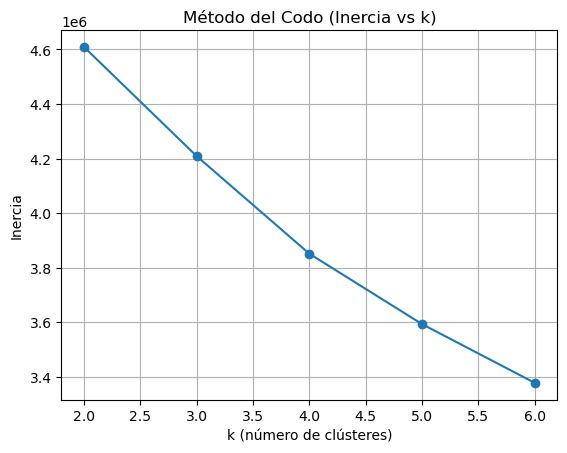

In [12]:
import matplotlib.pyplot as plt

plt.plot(ks, inertias, marker="o")
plt.title("Método del Codo (Inercia vs k)")
plt.xlabel("k (número de clústeres)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()


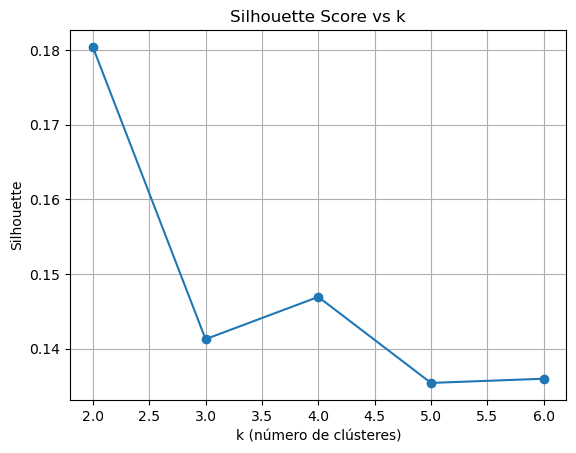

In [13]:
plt.plot(ks, sil_scores, marker="o")
plt.title("Silhouette Score vs k")
plt.xlabel("k (número de clústeres)")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()


In [15]:
k_opt = ks[int(np.argmax(sil_scores))]  # el mejor por silhouette
k_opt

best_pipe = Pipeline([
    ("pre", pre),
    ("kmeans", KMeans(n_clusters=int(k_opt), n_init="auto", random_state=42))
])

work["cluster"] = best_pipe.fit_predict(X)
work.head()


,incidente_id,latitud,longitud,mes,dia_semana,hora,categoria,rol_usuario,estado,cluster
0,1,20.0535,-101.2850,8,3,20,Servicios públicos,ciudadano,descartado,0
1,2,19.3995,-100.7210,8,4,20,Servicios públicos,ciudadano,atendido,0
2,3,20.0304,-98.8305,8,1,20,Seguridad pública,ciudadano,en_revision,0
3,4,20.3664,-99.0906,7,2,20,Medio ambiente,ciudadano,pendiente,0
4,5,21.4933,-101.3300,7,1,20,Medio ambiente,ciudadano,pendiente,0


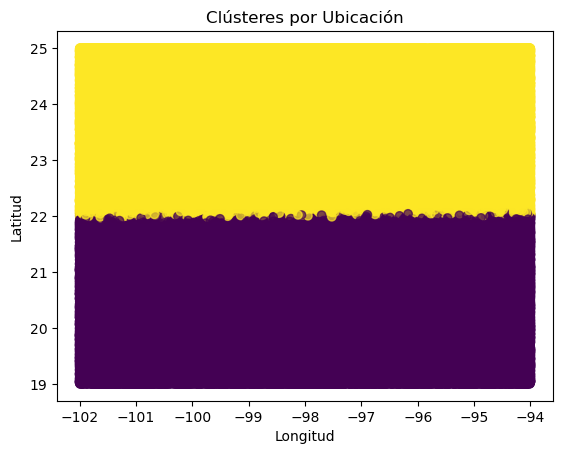

In [16]:
plt.scatter(work["longitud"], work["latitud"], c=work["cluster"], alpha=0.7)
plt.title("Clústeres por Ubicación")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()


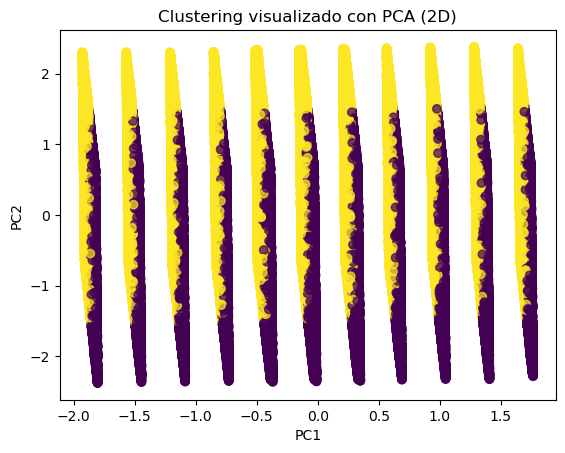

Varianza explicada: [0.18689765 0.17834742]


In [17]:
from sklearn.decomposition import PCA

Z = best_pipe.named_steps["pre"].transform(X)
pca = PCA(n_components=2, random_state=42)
Z2 = pca.fit_transform(Z)

plt.scatter(Z2[:,0], Z2[:,1], c=work["cluster"], alpha=0.7)
plt.title("Clustering visualizado con PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Varianza explicada:", pca.explained_variance_ratio_)


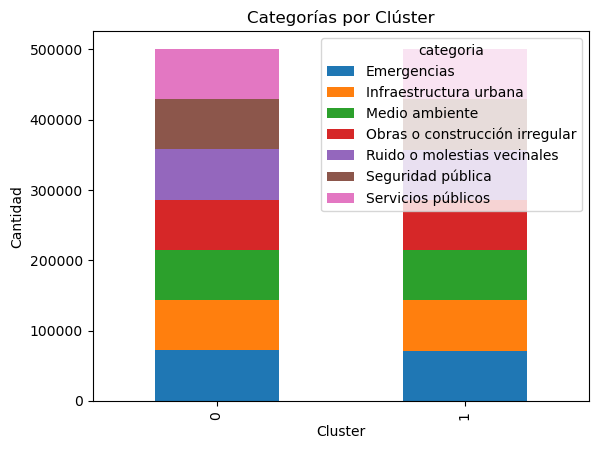

In [18]:
(
    work.groupby(["cluster","categoria"])
        .size()
        .unstack(fill_value=0)
        .plot(kind="bar", stacked=True)
)
plt.title("Categorías por Clúster")
plt.ylabel("Cantidad")
plt.xlabel("Cluster")
plt.show()


In [21]:
# === CÁLCULO RÁPIDO DEL RESUMEN (sin re-transformar todo) ===
import numpy as np
from sklearn.metrics import silhouette_score

# Usa la matriz ya transformada que tengas disponible:
# - Opción A: Z  (pre + scaler + one-hot)
# - Opción B: Zs (pre + SVD/TruncatedSVD)
features = locals().get("Zs", None) or locals().get("Z", None)
if features is None:
    raise RuntimeError("No encuentro Z/Zs. Ejecuta antes la celda donde transformas X.")

labels = work["cluster"].to_numpy()
k_used = int(np.unique(labels).size) if "k_opt" not in globals() else int(k_opt)

# Muestra para acelerar silhouette
sample_n = min(2000, len(labels))  # baja a 1000 si sigue tardando
rng = np.random.RandomState(42)
idx = rng.choice(len(labels), size=sample_n, replace=False)

sil = float(silhouette_score(features[idx], labels[idx]))

resumen = {
    "n_incidentes": int(len(work)),
    "n_clusters": int(np.unique(labels).size),
    "k_usado": k_used,
    "silhouette_final": round(sil, 4),
}
resumen


{'n_incidentes': 1001000,
 'n_clusters': 2,
 'k_usado': 2,
 'silhouette_final': 0.1252}

In [22]:
# Top categorías por clúster
top_cats = (
    work.groupby(["cluster","categoria"]).size()
        .reset_index(name="conteo")
        .sort_values(["cluster","conteo"], ascending=[True, False])
)
top_cats.head(15)


,cluster,categoria,conteo
0,0,Emergencias,71688
5,0,Seguridad pública,71617
1,0,Infraestructura urbana,71614
4,0,Ruido o molestias vecinales,71508
2,0,Medio ambiente,71465
3,0,Obras o construcción irregular,71401
6,0,Servicios públicos,71343
12,1,Seguridad pública,72041
13,1,Servicios públicos,71473
8,1,Infraestructura urbana,71463


In [23]:
md(f"""
## Resultados Obtenidos
- Total de incidentes analizados: **{resumen['n_incidentes']}**
- Número de clústeres encontrados: **{resumen['n_clusters']}** (k = **{resumen['k_usado']}**)
- Silhouette Score del modelo final: **{resumen['silhouette_final']:.3f}**

**Hallazgos (ejemplos a redactar según tus datos):**
- Un clúster concentra incidentes de *Seguridad pública* en horarios nocturnos.
- Otro clúster agrupa reportes de *Servicios públicos* (alumbrado/agua) en horarios laborales.
- Se observan **zonas geográficas** con mayor densidad para *Infraestructura*.

> Ajusta esta redacción con base en tus tablas y gráficos.
""")



## Resultados Obtenidos
- Total de incidentes analizados: **1001000**
- Número de clústeres encontrados: **2** (k = **2**)
- Silhouette Score del modelo final: **0.125**

**Hallazgos (ejemplos a redactar según tus datos):**
- Un clúster concentra incidentes de *Seguridad pública* en horarios nocturnos.
- Otro clúster agrupa reportes de *Servicios públicos* (alumbrado/agua) en horarios laborales.
- Se observan **zonas geográficas** con mayor densidad para *Infraestructura*.

> Ajusta esta redacción con base en tus tablas y gráficos.


In [24]:
md("""
## Conclusión de la Fase del Proyecto
El análisis no supervisado permitió **descubrir patrones** en los reportes ciudadanos sin etiquetas previas, generando clusters útiles para:
- **Priorizar atención** por zona y tipo de incidente.
- **Planear operativos** en horarios de mayor incidencia.
- **Optimizar servicios públicos** (alumbrado, fugas, baches).

**Siguientes pasos**:
1) Incorporar variables adicionales (densidad por colonia, gravedad, tiempo de resolución).  
2) Probar otros algoritmos (DBSCAN, Gaussian Mixture) y comparar métricas.  
3) Integrar este resultado al **dashboard** para monitoreo continuo.
""")



## Conclusión de la Fase del Proyecto
El análisis no supervisado permitió **descubrir patrones** en los reportes ciudadanos sin etiquetas previas, generando clusters útiles para:
- **Priorizar atención** por zona y tipo de incidente.
- **Planear operativos** en horarios de mayor incidencia.
- **Optimizar servicios públicos** (alumbrado, fugas, baches).

**Siguientes pasos**:
1) Incorporar variables adicionales (densidad por colonia, gravedad, tiempo de resolución).  
2) Probar otros algoritmos (DBSCAN, Gaussian Mixture) y comparar métricas.  
3) Integrar este resultado al **dashboard** para monitoreo continuo.
